# Demeaned Prediction Overview

This notebook creates two validation-subject figures:

1. Ground-truth FC overview: subject FC, population-mean FC, and demeaned FC.
2. Demeaned prediction comparison: `Krakencoder`, `Null` (`CrossModalPCA` from SC), and `Oracle` (`CrossModalPCA` from FC), with optional demeaned ground truth and demeaned Pearson `r`.

In [1]:
# Reload helpers in place while iterating on the figures.
import sys
from pathlib import Path
import importlib

import numpy as np

REPO_ROOT = Path('/scratch/asr655/neuroinformatics/Conn2Conn')
sys.path.insert(0, str(REPO_ROOT))

import data.hcp_dataset as hcp_dataset
import data.demeaned_viz as demeaned_viz
importlib.reload(hcp_dataset)
importlib.reload(demeaned_viz)

from data.hcp_dataset import HCP_Base
from data.demeaned_viz import (
    fit_pca_models,
    plot_demeaned_predictions,
    plot_ground_truth_demeaning,
    predict_single_subject,
    resolve_subject_id_and_indices,
)


In [2]:
PARCELLATION = 'Glasser'
SHUFFLE_SEED = 0
DATA_LOAD_MODE = 'precomputed'
NUM_PCA_COMPONENTS = 256
KRAKEN_PREDICTIONS_DIR = None

# Choose one validation subject either by validation position or by subject id.
VAL_POSITION = 0
SUBJECT_ID = None  # e.g. '100408'

INCLUDE_GROUND_TRUTH_IN_PRED_FIG = False


In [3]:
base_sc = HCP_Base(
    parcellation=PARCELLATION,
    shuffle_seed=SHUFFLE_SEED,
    source='SC',
    target='FC',
    data_load_mode=DATA_LOAD_MODE,
    write_manual_cache=False,
)

base_fc = HCP_Base(
    parcellation=PARCELLATION,
    shuffle_seed=SHUFFLE_SEED,
    source='FC',
    target='FC',
    data_load_mode=DATA_LOAD_MODE,
    write_manual_cache=False,
)

val_indices = np.asarray(base_sc.trainvaltest_partition_indices['val'])
print(f'Validation subjects: {len(val_indices)}')


/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Validation subjects: 79


In [4]:
subject_id, val_position, global_idx_sc, global_idx_fc = resolve_subject_id_and_indices(
    base_sc,
    base_fc,
    val_position=VAL_POSITION,
    subject_id=SUBJECT_ID,
)

print('subject_id:', subject_id)
print('val_position:', val_position)
print('global_idx_sc:', global_idx_sc)
print('global_idx_fc:', global_idx_fc)


subject_id: 100408
val_position: 0
global_idx_sc: 2
global_idx_fc: 2


In [5]:
null_model, oracle_model, kraken_model, device = fit_pca_models(
    base_sc,
    base_fc,
    num_components=NUM_PCA_COMPONENTS,
    kraken_predictions_dir=KRAKEN_PREDICTIONS_DIR,
)

y_true, null_pred, oracle_pred, kraken_pred = predict_single_subject(
    null_model,
    oracle_model,
    kraken_model,
    base_sc,
    base_fc,
    global_idx_sc,
    global_idx_fc,
    device,
)

print('Prediction vectors loaded for subject', subject_id)


Source mean shape: torch.Size([64620])
Source loadings shape: torch.Size([64620, 683])
Target mean shape: torch.Size([64620])
Target loadings shape: torch.Size([64620, 683])
Source mean shape: torch.Size([64620])
Source loadings shape: torch.Size([64620, 683])
Target mean shape: torch.Size([64620])
Target loadings shape: torch.Size([64620, 683])
KrakencoderPrecomputed: loaded  seed=0  parc=Glasser  source=SC  shape=(957, 64620)
Prediction vectors loaded for subject 100408


In [15]:
import importlib

import data.hcp_dataset as hcp_dataset
import data.demeaned_viz as demeaned_viz

importlib.reload(hcp_dataset)
importlib.reload(demeaned_viz)

from data.hcp_dataset import HCP_Base
from data.demeaned_viz import (
    resolve_subject_id_and_indices,
    fit_pca_models,
    predict_single_subject,
    plot_ground_truth_demeaning,
    plot_demeaned_predictions,
)


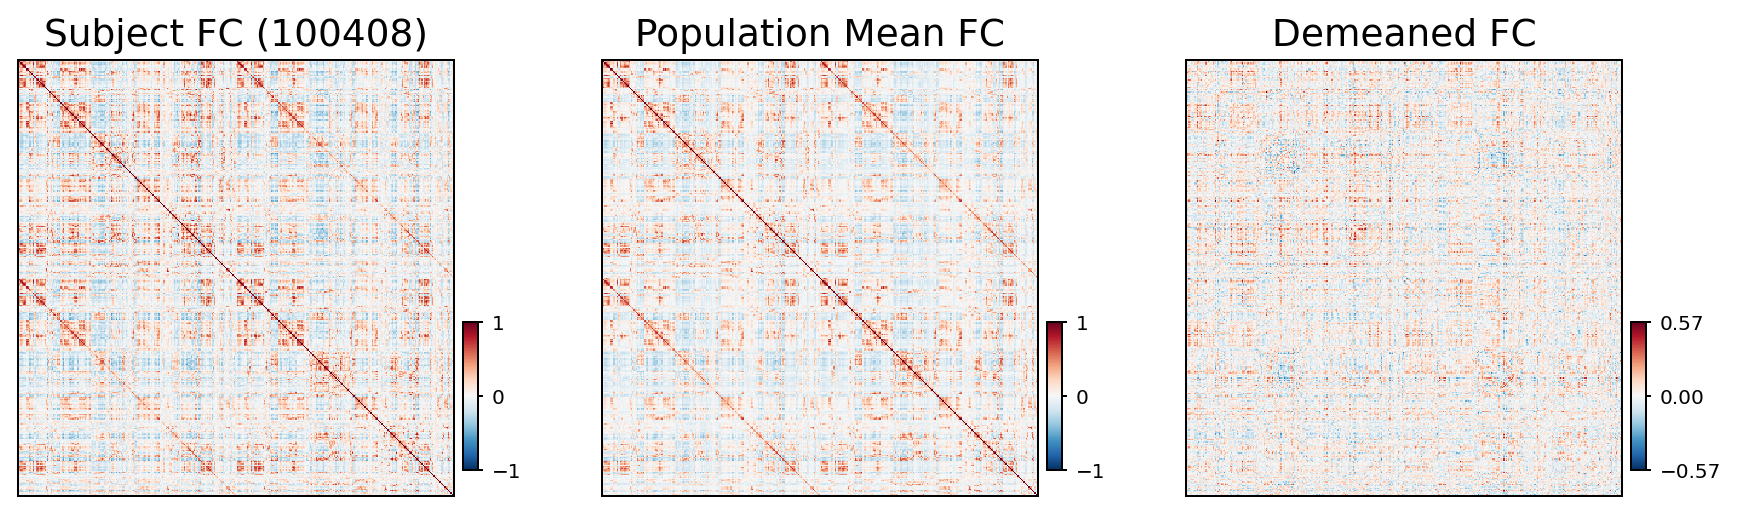

In [16]:
fig, axes = plot_ground_truth_demeaning(
    base_sc,
    subject_id=subject_id,
    global_idx_sc=global_idx_sc,
)


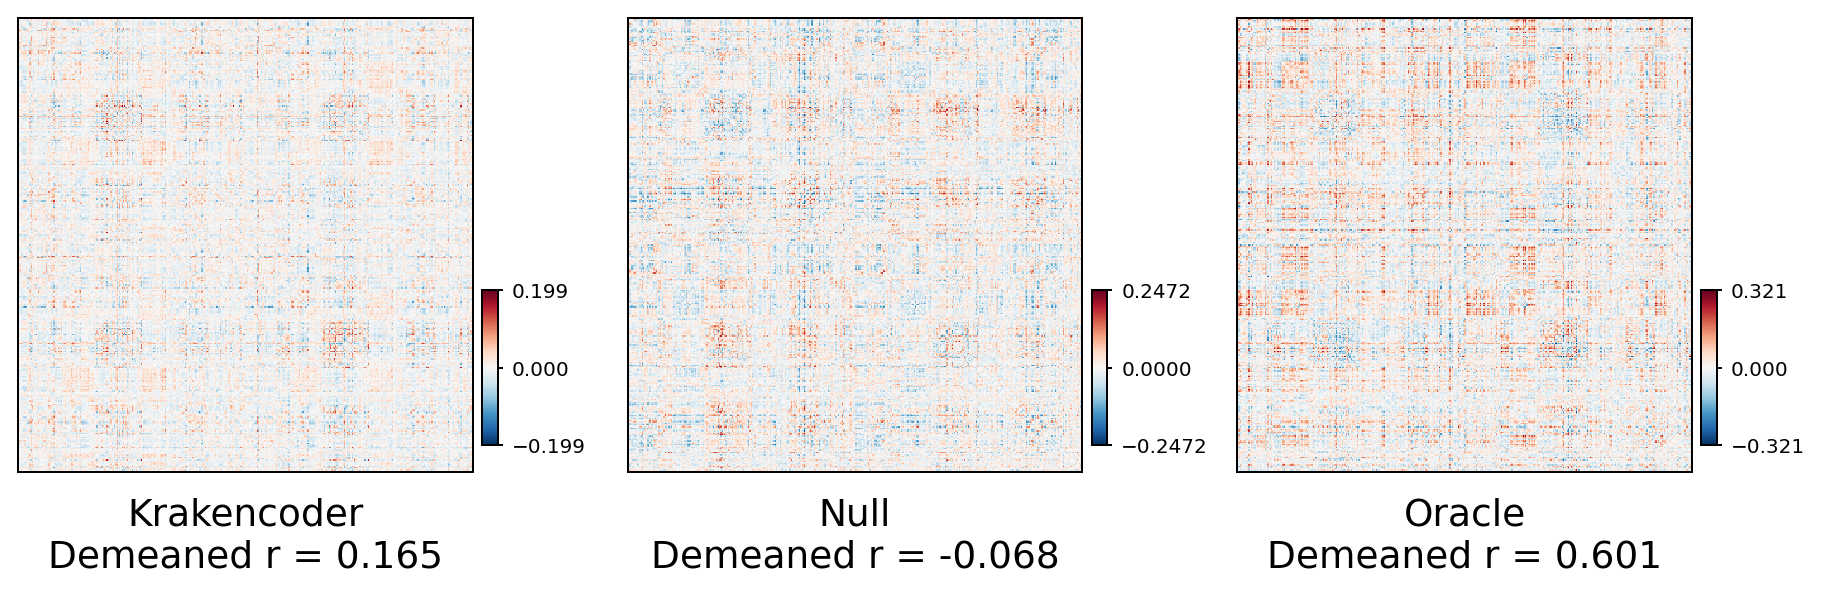

In [17]:
fig, axes = plot_demeaned_predictions(
    base_sc,
    subject_id=subject_id,
    y_true=y_true,
    kraken_pred=kraken_pred,
    null_pred=null_pred,
    oracle_pred=oracle_pred,
    include_ground_truth=INCLUDE_GROUND_TRUTH_IN_PRED_FIG,
    shared_range=False,
)
